# 05 — De spikes a fuerza muscular simplificada

Cada spike del pool motor genera un *twitch* causal:

$
h(t)=A\left(e^{-t/\tau_{\mathrm{decay}}}
-e^{-t/\tau_{\mathrm{rise}}}\right),\quad t \ge 0
$

La señal de fuerza es la suma lineal de todos los twitches. Es un proxy de activación/contracción, no un modelo de unidades motoras, fatiga, longitud-tensión o biomecánica articular.

## Por qué se usa este twitch

Un spike neuronal es un evento muy breve, pero una contracción muscular elemental sube y decae más lentamente. La diferencia de exponenciales proporciona ese perfil con dos parámetros interpretables:

$
h(t)=A\left(e^{-t/\tau_{decay}}-e^{-t/\tau_{rise}}\right),\quad t\ge 0
$

- `tau_rise`: subida rápida de la respuesta.
- `tau_decay`: relajación más lenta; debe ser mayor que `tau_rise`.
- `A`: escala del twitch. En `twitch_response` el kernel se normaliza para que su pico coincida con la amplitud solicitada.

Se eligió porque es causal, simple, positiva con `tau_decay > tau_rise`, fácil de visualizar y suficiente para estudiar sumación temporal. No modela calcio, reclutamiento de unidades motoras, fatiga ni relación longitud–tensión.

### Flujo spikes → fuerza

In [ ]:
from src.visualization import plot_spikes_to_force_flow

plot_spikes_to_force_flow()
plt.show()

In [2]:
from pathlib import Path
import sys

# Funciona si el kernel inicia en la raíz o dentro de notebooks/.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import ipywidgets as widgets
from IPython.display import HTML, display, clear_output

from src.metrics import force_summary, neural_summary, population_activity
from src.muscle import normalize_force, spikes_to_force
from src.renshaw import simulate_renshaw_circuit
from src.visualization import animate_muscle_contraction, plot_raster, plot_renshaw_circuit, spike_times_from_matrix


In [3]:
BASE = dict(n_motor=20, n_renshaw=5, amplitude=12., input_type="motor_plan",
            parameter_noise=.03, input_noise=.5, p_mn_to_r=.5, w_mn_to_r=1.5,
            p_r_to_mn=.6, synaptic_tau=10., total_time=1000., dt=.5, seed=42)
SCENARIOS = {
    "Sin Renshaw": dict(w_r_to_mn=0., recurrent_inhibition=False),
    "Moderada": dict(w_r_to_mn=1.5, recurrent_inhibition=True),
    "Fuerte": dict(w_r_to_mn=4., recurrent_inhibition=True),
}
results, forces, summaries = {}, {}, []
for name, change in SCENARIOS.items():
    result = simulate_renshaw_circuit(**BASE, **change)
    force = spikes_to_force(result["spikes_MN"], result["time"], amplitude=1., tau_rise_ms=10., tau_decay_ms=50.)
    results[name], forces[name] = result, force
    summaries.append({"escenario": name, **force_summary(force, result["time"])})
force_table = pd.DataFrame(summaries).set_index("escenario")
force_table


,max_force,mean_force,time_to_peak_ms
escenario,,,
Sin Renshaw,41.083071,23.221799,568.5
Moderada,41.032358,21.960262,663.0
Fuerte,40.578965,21.581652,512.0


## Cómo se convierten los spikes en fuerza

La matriz `spikes_MN` tiene forma `(motoneuronas, tiempo)` y contiene `True/1` cuando una MN dispara.

1. Se suman las filas para obtener impulsos poblacionales por instante.
2. Se construye el kernel twitch para el mismo `dt`.
3. Se aplica una convolución causal:

$
F[t]=\sum_{k=0}^{t} impulses[k]h[t-k]
$

4. Si llegan varios spikes antes de que el twitch anterior decaiga, sus respuestas se superponen y la fuerza aumenta.

Ejemplo conceptual:

```text
spike aislado       → un twitch aislado
spikes cercanos     → twitches superpuestos → mayor pico
menos spikes        → normalmente menor fuerza media
mismo nº de spikes  → el pico puede cambiar si cambia su timing
```

La fuerza está en unidades arbitrarias. Como es una transformación determinista de los spikes, no constituye una validación independiente del circuito neuronal.

## Métricas musculares

- **Fuerza máxima**: mayor suma instantánea de twitches. Es sensible al agrupamiento temporal de spikes.
- **Fuerza media**: promedio de toda la señal, incluyendo reposo. Está fuertemente relacionada con la cantidad total de spikes.
- **Tiempo hasta el pico**: instante del máximo global; puede cambiar aunque la fuerza media siga una tendencia regular.
- **Fuerza normalizada**: divide por el máximo para obtener valores entre 0 y 1. Sirve para animación, pero elimina diferencias absolutas entre escenarios.

La elipse animada traduce la activación normalizada a ancho y largo. Es una metáfora visual de contracción, no una reconstrucción anatómica.

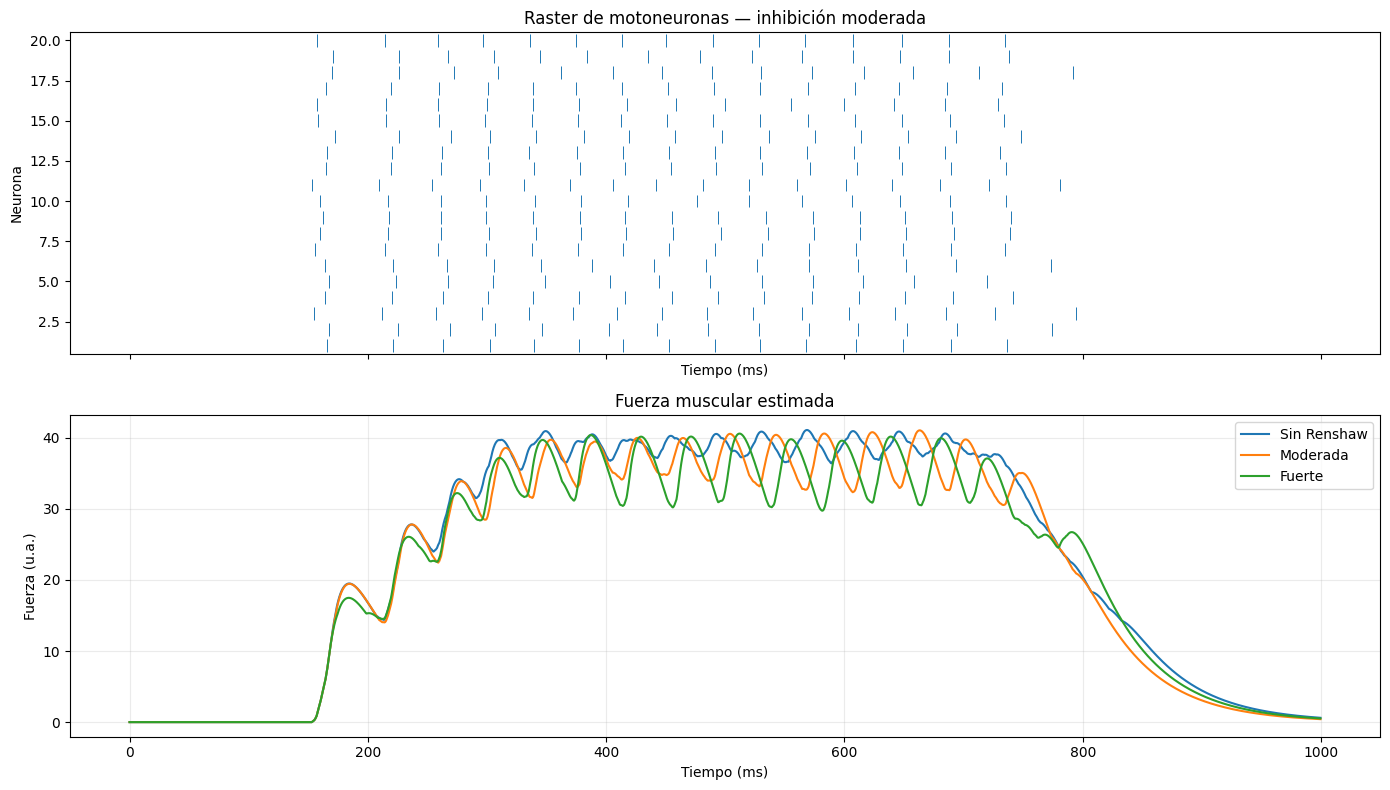

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
reference = results["Moderada"]
plot_raster(spike_times_from_matrix(reference["spikes_MN"], reference["time"]), axes[0])
axes[0].set_title("Raster de motoneuronas — inhibición moderada")
for name, force in forces.items():
    axes[1].plot(reference["time"], force, label=name)
axes[1].set(title="Fuerza muscular estimada", xlabel="Tiempo (ms)", ylabel="Fuerza (u.a.)")
axes[1].legend(); axes[1].grid(alpha=.25)
fig.tight_layout(); plt.show()


## Visualización 2D de contracción

La elipse se acorta y ensancha según la fuerza normalizada. Es deliberadamente esquemática: representa activación/contracción visual, **no anatomía real** ni movimiento de una extremidad.

In [5]:
moderate_force = normalize_force(forces["Moderada"])
muscle_animation = animate_muscle_contraction(results["Moderada"]["time"], moderate_force)
plt.close(muscle_animation._fig)  # evita una figura estática duplicada
display(HTML(muscle_animation.to_jshtml()))


In [6]:
moderate_force = normalize_force(forces["Sin Renshaw"])
muscle_animation = animate_muscle_contraction(results["Sin Renshaw"]["time"], moderate_force)
plt.close(muscle_animation._fig)  # evita una figura estática duplicada
display(HTML(muscle_animation.to_jshtml()))

## Lectura prudente

En este modelo lineal, menos spikes normalmente producen menos suma de twitches, pero la forma temporal también depende de cuándo ocurren. Las métricas (`max_force`, `mean_force`, `time_to_peak_ms`) describen únicamente esta señal artificial.